#  Predictive Modeling Using Regression

## Sales Forecasting Using Linear Regression

## Introduction

In the era of data-driven decision-making, predictive modeling stands at the forefront of analytics, enabling
organizations to anticipate outcomes and make informed decisions. Among the array of predictive techniques,
Linear Regression emerges as a cornerstone method, celebrated for its simplicity, interpretability, and effectiveness.
This statistical approach delivers accurate, reliable forecasts by modeling the relationship between a dependent variable
and one or more independent variables, fitting a straight line through historical data. Linear Regression forms the backbone
of many machine learning and data science solutions, making it an essential tool for any aspiring analyst or data professional.

# Let's take a deep dive into the data

### Import necessary libraries

In [7]:
import pandas as pd
import os
import glob

In [8]:
folder_path = r"C:\Monthly_Sales"

# Retrieve all CSV files from the folder using glob
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

# All CSV files combined as one DataFrame 
all_data = pd.concat([pd.read_csv(file) for file in all_files], ignore_index=True)

# Merged DataFrame saved into a new CSV
output_file = os.path.join(folder_path, "all_data.csv")
all_data.to_csv(output_file, index=False)

print("All files integrated into:", output_file)

All files integrated into: C:\Monthly_Sales\all_data.csv


### Load the updated DataFrame

In [10]:
# Skip Blank Rows if present in the dataset

df = pd.read_csv(r'C:\Monthly_Sales\all_data.csv', skip_blank_lines=True)
df.head()

,Order ID,Product Name,Units Purchased,Unit Price,Order Date,Delivery Address
0,175667,iPhone,1,700.0,04/24/24 19:12,"135 Meadow St, Boston, MA 02215"
1,175668,AA Batteries (4-pack),1,5.84,04/20/24 13:45,"592 4th St, San Francisco, CA 94016"
2,175669,AA Batteries (4-pack),1,5.84,04/28/24 09:17,"632 Park St, Dallas, TX 75001"
3,175670,AA Batteries (4-pack),2,5.84,04/23/24 14:06,"131 Pine St, San Francisco, CA 94016"
4,175671,Samsung Odyssey Monitor,1,409.99,04/23/24 12:13,"836 Forest St, Boston, MA 02215"


## Data Cleaning Process

Thoroughly clean and standardize the data to eliminate errors, ensure consistency, and build a solid foundation for meaningful insights.

### Find and remove rows with NaN values

In [13]:
df.isna().sum()

Order ID            16576
Product Name        16576
Units Purchased     16577
Unit Price          16577
Order Date          16577
Delivery Address    16578
dtype: int64

In [14]:
# If Nan value is present in Order ID and Unit Purchased, it will be impossible to manipulate the data.
# Therefore, drop Nan values in Order ID and Units Purchased.

df.dropna(subset=['Order ID', 'Units Purchased'], inplace=True)

# Check if Nan value is present
df.isna().sum()

Order ID            0
Product Name        0
Units Purchased     0
Unit Price          0
Order Date          0
Delivery Address    1
dtype: int64

In [15]:
# Further check if any NaN values or blank rows are present

blank_rows_na = df[df.isnull().any(axis=1)]
blank_rows_na

,Order ID,Product Name,Units Purchased,Unit Price,Order Date,Delivery Address
2195228,Charging Cable,1,14.95,05/24/24 07:04,"852 Hickory St, San Francisco, CA 94016",NaN


### Find and remove rows with duplicate values

In [17]:
# Find duplicate values

df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
6383643     True
6383644     True
6383645     True
6383646     True
6383647     True
Length: 6367071, dtype: bool

In [18]:
# Check again for duplicated values

df.drop_duplicates(inplace = True)

# Check again for duplicated values
df.duplicated()

0          False
1          False
2          False
3          False
4          False
           ...  
172528     False
172529     False
172530     False
1012522    False
2195228    False
Length: 171544, dtype: bool

### Verify and fix incorrect data types in the dataset

In [20]:
# check for data types

df.dtypes

Order ID            object
Product Name        object
Units Purchased     object
Unit Price          object
Order Date          object
Delivery Address    object
dtype: object

### Fix incorrect data types

In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%y %H:%M', errors='coerce')

df['Units Purchased'] = pd. to_numeric(df['Units Purchased'], errors='coerce')

df['Unit Price'] = pd. to_numeric(df['Unit Price'], errors='coerce')

In [23]:
# Verify the presence of NaN values remaining in the columns as a result of using errors='coerce' during data conversion.

df.isna().sum()

Order ID            0
Product Name        0
Units Purchased     2
Unit Price          2
Order Date          2
Delivery Address    1
dtype: int64

In [59]:
df = df.dropna()

### Change the data type to optimize memory usage (Optional)

In [26]:
df['Order ID'] = pd.to_numeric(df['Order ID'], downcast='integer') 
df['Product Name'] = df['Product Name'].astype('category')  
df['Units Purchased'] = df['Units Purchased']. astype('int8') 
df['Unit Price'] = pd.to_numeric(df['Unit Price'], downcast='float')   
df['Delivery Address'] = df['Delivery Address'].astype('category') 

## Expand the dataset with supplementary columns

In [28]:
# Add Month and Year 
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

df

,Order ID,Product Name,Units Purchased,Unit Price,Order Date,Delivery Address,Month,Year
0,175667,iPhone,1,700.00000,2024-04-24 19:12:00,"135 Meadow St, Boston, MA 02215",4,2024
1,175668,AA Batteries (4-pack),1,5.84000,2024-04-20 13:45:00,"592 4th St, San Francisco, CA 94016",4,2024
2,175669,AA Batteries (4-pack),1,5.84000,2024-04-28 09:17:00,"632 Park St, Dallas, TX 75001",4,2024
3,175670,AA Batteries (4-pack),2,5.84000,2024-04-23 14:06:00,"131 Pine St, San Francisco, CA 94016",4,2024
4,175671,Samsung Odyssey Monitor,1,409.98999,2024-04-23 12:13:00,"836 Forest St, Boston, MA 02215",4,2024
...,...,...,...,...,...,...,...,...
172526,248376,Apple Airpods Headphones,1,150.00000,2024-09-24 12:23:00,"517 Lincoln St, Portland, OR 97035",9,2024
172527,248377,Apple Airpods Headphones,1,150.00000,2024-09-08 13:44:00,"189 West St, Los Angeles, CA 90001",9,2024
172528,248378,Google Phone,1,600.00000,2024-09-02 08:53:00,"668 Wilson St, Boston, MA 02215",9,2024
172529,248379,Alienware Monitor,1,400.98999,2024-09-04 22:58:00,"466 2nd St, Boston, MA 02215",9,2024


In [29]:
# Add Total Sales column

df['Total Sales'] = df['Units Purchased'] * df['Unit Price']
df.head()

,Order ID,Product Name,Units Purchased,Unit Price,Order Date,Delivery Address,Month,Year,Total Sales
0,175667,iPhone,1,700.00000,2024-04-24 19:12:00,"135 Meadow St, Boston, MA 02215",4,2024,700.00000
1,175668,AA Batteries (4-pack),1,5.84000,2024-04-20 13:45:00,"592 4th St, San Francisco, CA 94016",4,2024,5.84000
2,175669,AA Batteries (4-pack),1,5.84000,2024-04-28 09:17:00,"632 Park St, Dallas, TX 75001",4,2024,5.84000
3,175670,AA Batteries (4-pack),2,5.84000,2024-04-23 14:06:00,"131 Pine St, San Francisco, CA 94016",4,2024,11.68000
4,175671,Samsung Odyssey Monitor,1,409.98999,2024-04-23 12:13:00,"836 Forest St, Boston, MA 02215",4,2024,409.98999


### Format Unit Price and Total Sales to 2 decimal places

In [31]:
df['Unit Price'] = df['Unit Price'].apply(lambda x: "%.2f" % x)

df['Total Sales'] = df['Total Sales'].apply(lambda x: "%.2f" % x)
df.head()

,Order ID,Product Name,Units Purchased,Unit Price,Order Date,Delivery Address,Month,Year,Total Sales
0,175667,iPhone,1,700.00,2024-04-24 19:12:00,"135 Meadow St, Boston, MA 02215",4,2024,700.00
1,175668,AA Batteries (4-pack),1,5.84,2024-04-20 13:45:00,"592 4th St, San Francisco, CA 94016",4,2024,5.84
2,175669,AA Batteries (4-pack),1,5.84,2024-04-28 09:17:00,"632 Park St, Dallas, TX 75001",4,2024,5.84
3,175670,AA Batteries (4-pack),2,5.84,2024-04-23 14:06:00,"131 Pine St, San Francisco, CA 94016",4,2024,11.68
4,175671,Samsung Odyssey Monitor,1,409.99,2024-04-23 12:13:00,"836 Forest St, Boston, MA 02215",4,2024,409.99


In [32]:
# Convert from string to numeric

df['Unit Price'] = pd.to_numeric(df['Unit Price'])
df['Total Sales'] = pd.to_numeric(df['Total Sales'])

In [33]:
df.dtypes

Order ID                     int32
Product Name              category
Units Purchased               int8
Unit Price                 float64
Order Date          datetime64[ns]
Delivery Address          category
Month                        int32
Year                         int32
Total Sales                float64
dtype: object

### Organize Data by Order Date Chronologically and Reindex

In [35]:
df = df.sort_values(by = 'Order Date')

df = df.reset_index(drop=True)
df

,Order ID,Product Name,Units Purchased,Unit Price,Order Date,Delivery Address,Month,Year,Total Sales
0,151041,AAA Batteries (4-pack),1,4.99,2024-01-01 05:04:00,"964 Lakeview St, Atlanta, GA 30301",1,2024,4.99
1,160155,Alienware Monitor,1,400.99,2024-01-01 05:04:00,"765 Ridge St, Portland, OR 97035",1,2024,400.99
2,146765,AAA Batteries (4-pack),1,4.99,2024-01-01 05:20:00,"546 10th St, San Francisco, CA 94016",1,2024,4.99
3,145617,Amana Washing Machine,1,600.00,2024-01-01 05:24:00,"961 Meadow St, Portland, OR 97035",1,2024,600.00
4,156535,Lightning Charging Cable,2,14.95,2024-01-01 05:45:00,"451 Elm St, Los Angeles, CA 90001",1,2024,29.90
...,...,...,...,...,...,...,...,...,...
171536,297748,USB-C Charging Cable,2,11.95,2025-01-01 02:37:00,"258 Forest St, Los Angeles, CA 90001",1,2025,23.90
171537,284606,Bose SoundSport Headphones,1,99.99,2025-01-01 02:50:00,"211 Johnson St, Boston, MA 02215",1,2025,99.99
171538,302330,AA Batteries (4-pack),1,5.84,2025-01-01 03:03:00,"665 6th St, San Francisco, CA 94016",1,2025,5.84
171539,284711,AA Batteries (4-pack),1,5.84,2025-01-01 03:19:00,"250 8th St, San Francisco, CA 94016",1,2025,5.84


## Sales Forecasting Using Linear Regression

### QUESTION: What will our monthly sales look like over the next two years based on historical purchasing patterns?

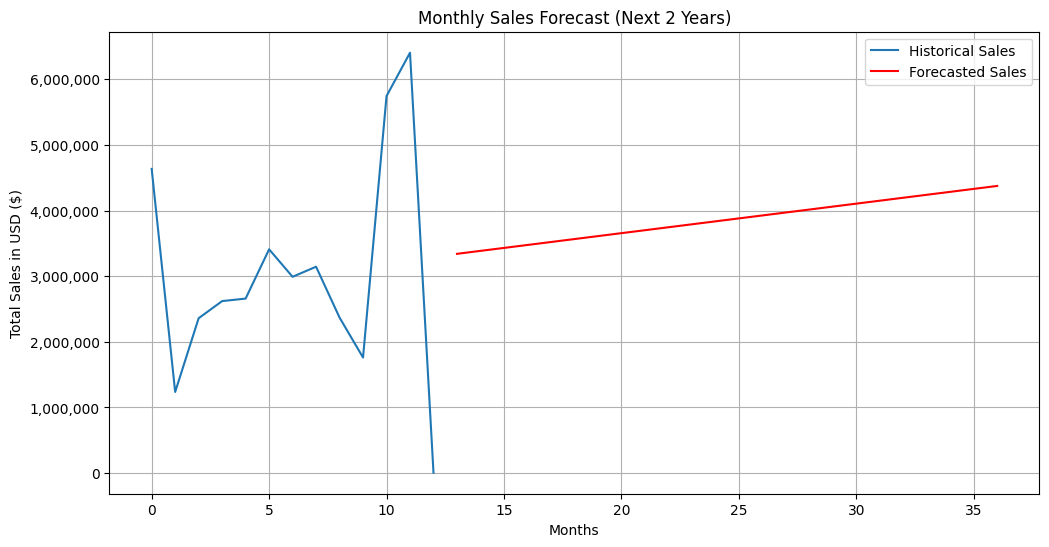

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from sklearn.linear_model import LinearRegression

monthly_sales = df.groupby(['Year', 'Month'])['Total Sales'].sum().reset_index()

# Time Index' for regression (e.g., 0, 1, 2, ..., n)
monthly_sales = monthly_sales.sort_values(['Year', 'Month'])
monthly_sales['Time'] = np.arange(len(monthly_sales))

# Linear Regression model
X = monthly_sales[['Time']]
y = monthly_sales['Total Sales']

model = LinearRegression()
model.fit(X, y)

# Forecast for next 24 months (2 years)
future_time = pd.DataFrame({'Time': np.arange(len(monthly_sales), len(monthly_sales) + 24)})
future_sales = model.predict(future_time)

# Future date labels
last_year = monthly_sales['Year'].max()
last_month = monthly_sales['Month'].max()
start_date = pd.Timestamp(year=last_year, month=last_month, day=1) + pd.DateOffset(months=1)
future_dates = pd.date_range(start=start_date, periods=24, freq='MS')

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['Time'], y, label='Historical Sales')
plt.plot(future_time, future_sales, label='Forecasted Sales', color='red')
plt.title('Monthly Sales Forecast (Next 2 Years)')
plt.xlabel('Months')
plt.ylabel('Total Sales in USD ($)')
plt.legend()
plt.grid(True)

# Format Y-axis to numeric (non-scientific)
formatter = FuncFormatter(lambda x, _: f'{x:,.0f}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.show()